In [ ]:
# Assignment No.06
# Deokar Shraddha Sunil
# TY - B - 153

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("sales_dataset.csv")
print(df.head())

   year  month shop_id   product_id  sales_qty
0     2      2  shop_0  product_268       2.00
1     2      4  shop_0  product_268       2.00
2     2      9  shop_0  product_268       2.00
3     2      3  shop_0  product_269       0.95
4     2      7  shop_0  product_269       0.95


In [5]:
# Remove invalid months
df = df[(df['month'] >= 1) & (df['month'] <= 12)]

# Create Date column
df['Date'] = pd.to_datetime(
    df['year'].astype(str) + '-' + df['month'].astype(str) + '-01',
    errors='coerce'
)

# Drop invalid dates if any
df = df.dropna(subset=['Date'])

C:\Users\shrad\AppData\Local\Temp\ipykernel_11004\814684945.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(


In [6]:
monthly_sales = df.groupby('Date')['sales_qty'].sum()

In [7]:
monthly_sales = monthly_sales.sort_index()
print(monthly_sales.head())

Date
2001-01-01      575710.14
2001-01-02      524568.97
2001-01-03      314159.94
2001-01-04    38490793.79
2001-01-05    68065269.98
Name: sales_qty, dtype: float64


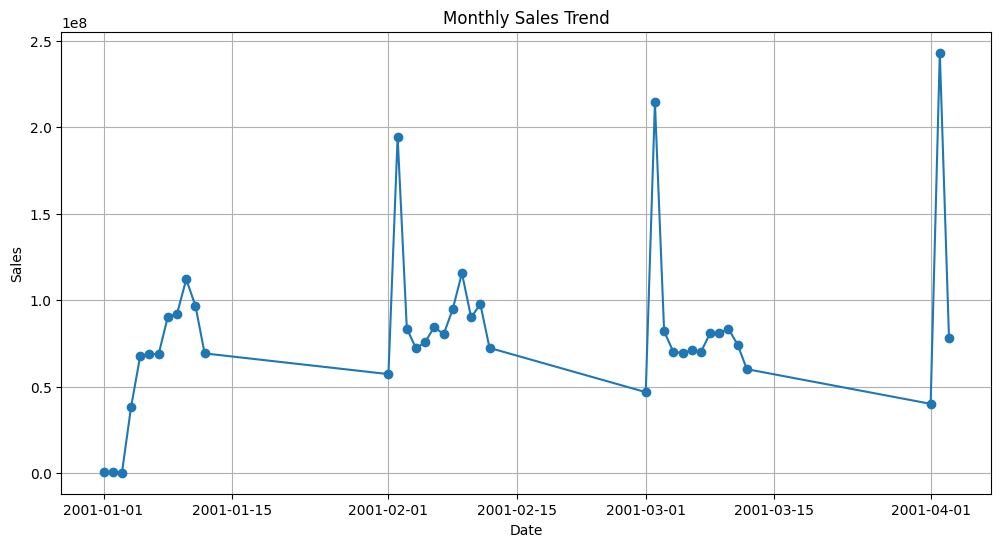

In [8]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [9]:
train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales[:train_size]
test = monthly_sales[train_size:]

In [10]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

C:\Users\shrad\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shrad\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shrad\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [11]:
predictions = model_fit.forecast(steps=len(test))

C:\Users\shrad\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\shrad\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


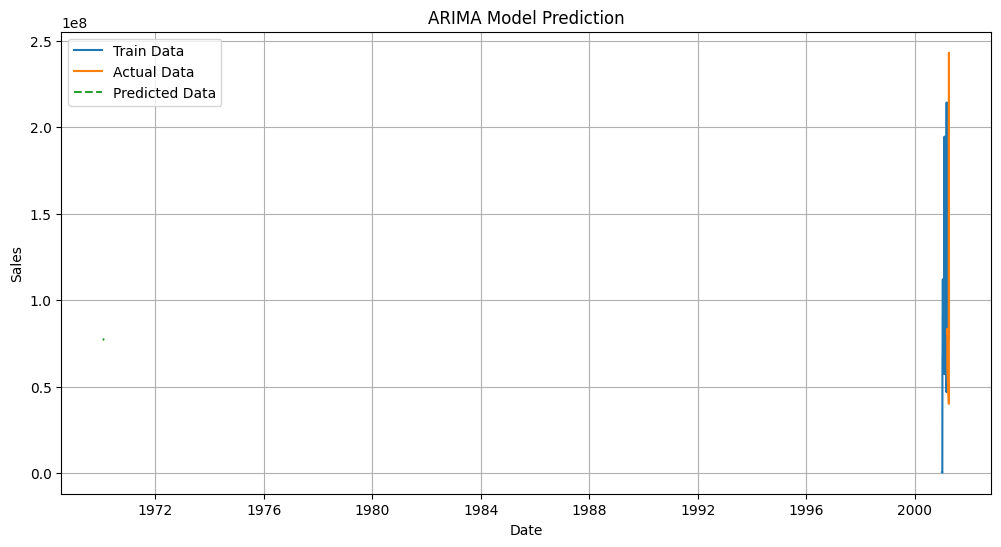

In [12]:
plt.figure(figsize=(12,6))
plt.plot(train, label='Train Data')
plt.plot(test, label='Actual Data')
plt.plot(predictions, label='Predicted Data', linestyle='--')
plt.title("ARIMA Model Prediction")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
rmse = np.sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

RMSE: 60460453.842844255


In [14]:
future_forecast = model_fit.forecast(steps=6)   # next 6 months
print("Future Forecast:\n", future_forecast)

Future Forecast:
 31    7.784930e+07
32    7.716596e+07
33    7.722638e+07
34    7.722104e+07
35    7.722151e+07
36    7.722147e+07
Name: predicted_mean, dtype: float64


C:\Users\shrad\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\shrad\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


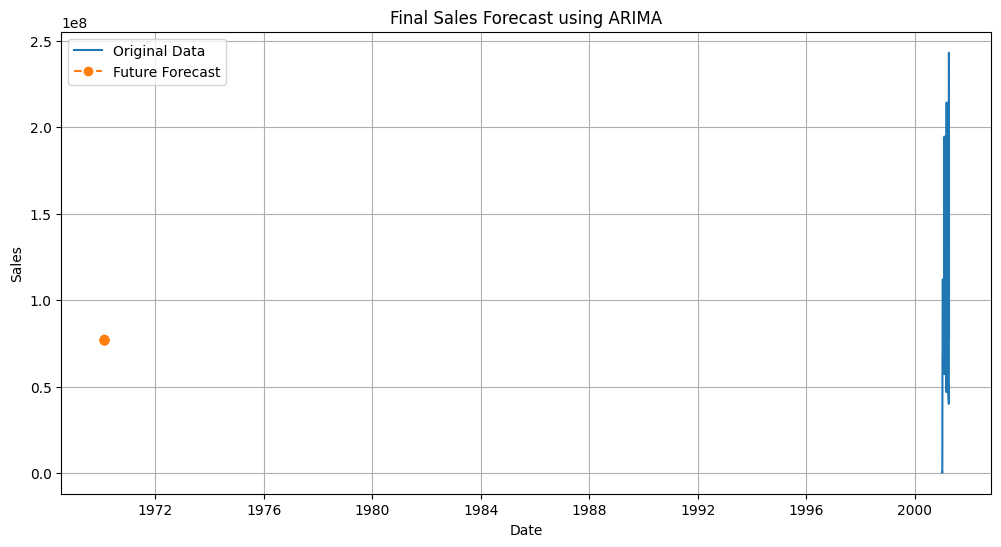

In [15]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales, label='Original Data')
plt.plot(future_forecast, label='Future Forecast', linestyle='--', marker='o')
plt.title("Final Sales Forecast using ARIMA")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()